01 — Data Inspection

**Purpose:** Load the Telco Customer Churn dataset and understand
its structure before any cleaning or modeling.

**Dataset:** data/raw/telco_customer_churn.csv

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

Pandas version: 2.3.3
NumPy version: 2.2.6


In [2]:
DATA_PATH = "../data/raw/telco_customer_churn.csv"

df = pd.read_csv(DATA_PATH)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 7043
Columns: 21


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values detected by pandas.")
else:
    print("Missing values per column:")
    print(missing)

No missing values detected by pandas.


In [7]:
blank_total_charges = (df["TotalCharges"].astype(str).str.strip() == "").sum()

print("Blank TotalCharges entries:", blank_total_charges)
print("TotalCharges dtype:", df["TotalCharges"].dtype)

Blank TotalCharges entries: 11
TotalCharges dtype: object


In [8]:
churn_counts = df["Churn"].value_counts()
churn_pct = df["Churn"].value_counts(normalize=True) * 100

print("Churn counts:")
print(churn_counts)

print()
print("Churn percentage:")
print(churn_pct.round(2))

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn percentage:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [9]:
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Categorical columns:", len(categorical_cols))
print()

for col in categorical_cols:
    unique_vals = df[col].nunique()
    print(f"{col:25s} → {unique_vals} unique values")

Categorical columns: 18

customerID                → 7043 unique values
gender                    → 2 unique values
Partner                   → 2 unique values
Dependents                → 2 unique values
PhoneService              → 2 unique values
MultipleLines             → 3 unique values
InternetService           → 3 unique values
OnlineSecurity            → 3 unique values
OnlineBackup              → 3 unique values
DeviceProtection          → 3 unique values
TechSupport               → 3 unique values
StreamingTV               → 3 unique values
StreamingMovies           → 3 unique values
Contract                  → 3 unique values
PaperlessBilling          → 2 unique values
PaymentMethod             → 4 unique values
TotalCharges              → 6531 unique values
Churn                     → 2 unique values


In [10]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

print("Numeric columns:", list(numeric_cols))
print()

for col in numeric_cols:
    print(
        f"{col:20s} "
        f"min={df[col].min()}   "
        f"max={df[col].max()}   "
        f"mean={df[col].mean():.2f}"
    )

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']

SeniorCitizen        min=0   max=1   mean=0.16
tenure               min=0   max=72   mean=32.37
MonthlyCharges       min=18.25   max=118.75   mean=64.76


## Day 2 — Findings Summary

**Dataset shape:** 7,043 rows × 21 columns.

**Target column:** `Churn` (Yes / No), currently stored as text.

**Class distribution:** Imbalanced — approximately 26–27% of
customers churned. This must be considered when choosing
evaluation metrics later.

**Data quality issues found so far:**

1. `TotalCharges` is stored as text (`object`) instead of a number.
2. `TotalCharges` contains a small number of blank entries that
   pandas does not detect as missing values.
3. `customerID` is a unique identifier with no predictive value
   and should be removed before modeling.
4. `Churn` needs to be converted from Yes/No text to 1/0 for
   machine learning.

**Next step (Day 3):** Clean the dataset — fix data types, handle
blanks, drop the ID column, and save a cleaned copy to
`data/processed/`.

---
## Day 3 — Data Cleaning
---

In [11]:
import pandas as pd
import numpy as np

# Load the raw dataset fresh for cleaning
df = pd.read_csv("../data/raw/telco_customer_churn.csv")

print("Shape before cleaning:", df.shape)
df.head(3)

Shape before cleaning: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [12]:
# Check all column types before cleaning
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [13]:
# Find rows where TotalCharges is blank
blank_mask = df["TotalCharges"].astype(str).str.strip() == ""

print("Number of blank TotalCharges rows:", blank_mask.sum())
print()
print("The rows with blank TotalCharges:")
df[blank_mask][["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Number of blank TotalCharges rows: 11

The rows with blank TotalCharges:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [14]:
# Step 1: Replace blank spaces with NaN
df["TotalCharges"] = df["TotalCharges"].str.strip()
df["TotalCharges"] = df["TotalCharges"].replace("", np.nan)

# Step 2: Convert to numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Step 3: Fill the 11 blank values with 0.0
df["TotalCharges"] = df["TotalCharges"].fillna(0.0)

# Verify
print("TotalCharges dtype after fix:", df["TotalCharges"].dtype)
print("Remaining NaN in TotalCharges:", df["TotalCharges"].isnull().sum())

TotalCharges dtype after fix: float64
Remaining NaN in TotalCharges: 0


In [15]:
print("Before conversion:")
print(df["Churn"].value_counts())
print("Dtype:", df["Churn"].dtype)

Before conversion:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Dtype: object


In [16]:
# Convert Churn: Yes → 1, No → 0
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Verify
print("After conversion:")
print(df["Churn"].value_counts())
print("Dtype:", df["Churn"].dtype)

After conversion:
Churn
0    5174
1    1869
Name: count, dtype: int64
Dtype: int64


In [17]:
# Drop customerID - it is an identifier, not a feature
print("Columns before drop:", df.shape[1])

df = df.drop(columns=["customerID"])

print("Columns after drop:", df.shape[1])
print("customerID still in df:", "customerID" in df.columns)

Columns before drop: 21
Columns after drop: 20
customerID still in df: False


In [18]:
# Check for duplicate rows
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 22


In [19]:
# Inspect the duplicate rows
duplicate_rows = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicate_rows))
duplicate_rows.head(30)

Total duplicate rows: 42


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
22,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,1
100,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,0
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,0
646,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,1
662,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,0
690,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,0
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,1
976,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,1
1243,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,45.30,45.30,1
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,1


In [20]:
# Check how many duplicate groups there are
print("Duplicate rows excluding first occurrence:", df.duplicated().sum())
print("Number of completely duplicated records:", df.duplicated(keep=False).sum())

Duplicate rows excluding first occurrence: 22
Number of completely duplicated records: 42


In [21]:
# Remove duplicate rows, keeping the first occurrence
before = df.shape[0]

df = df.drop_duplicates()

after = df.shape[0]

print("Rows before removing duplicates:", before)
print("Rows after removing duplicates:", after)
print("Rows removed:", before - after)

Rows before removing duplicates: 7043
Rows after removing duplicates: 7021
Rows removed: 22


In [22]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [23]:
# Final missing value check after cleaning
missing = df.isnull().sum()

print("Missing values per column:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Missing values per column:
No missing values found.


In [24]:
# Final shape check
print("Final cleaned shape:", df.shape)
print()

print("Column data types:")
print(df.dtypes)

Final cleaned shape: (7021, 20)

Column data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


In [25]:
# Preview the clean dataset
df.head(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [26]:
# Check basic statistics for numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7021.000000,7021.000000,7021.000000,7021.000000,7021.000000
mean,0.162512,32.469449,64.851894,2286.765026,0.264492
std,0.368947,24.534965,30.069001,2266.855057,0.441094
min,0.000000,0.000000,18.250000,0.000000,0.000000
25%,0.000000,9.000000,35.750000,403.350000,0.000000
50%,0.000000,29.000000,70.400000,1400.550000,0.000000
75%,0.000000,55.000000,89.900000,3801.700000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [27]:
import os

# Make sure the processed folder exists
os.makedirs("../data/processed", exist_ok=True)

# Save the cleaned dataset
output_path = "../data/processed/cleaned_churn_data.csv"
df.to_csv(output_path, index=False)

print("Cleaned dataset saved to:", output_path)

# Verify it was saved correctly by reloading
df_check = pd.read_csv(output_path)

print("Rows:", df_check.shape[0])
print("Columns:", df_check.shape[1])
print("TotalCharges dtype in saved file:", df_check["TotalCharges"].dtype)
print("Churn dtype in saved file:", df_check["Churn"].dtype)

Cleaned dataset saved to: ../data/processed/cleaned_churn_data.csv
Rows: 7021
Columns: 20
TotalCharges dtype in saved file: float64
Churn dtype in saved file: int64


# Day 4 — Exploratory Data Analysis

## Objectives

- Create a reproducible train-test split.
- Keep the test data untouched.
- Analyze churn distribution.
- Analyze churn by contract type.
- Compare tenure between churned and non-churned customers.
- Compare monthly charges between churned and non-churned customers.
- Save the figures for the project report and README.

In [28]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [29]:
current_directory = Path.cwd()

if (current_directory / "data").exists():
    PROJECT_ROOT = current_directory
elif (current_directory.parent / "data").exists():
    PROJECT_ROOT = current_directory.parent
else:
    raise FileNotFoundError(
        "Project root could not be found. "
        "Open the customer-churn-retention-engine folder in VS Code."
    )

CLEANED_DATA_PATH = (
    PROJECT_ROOT / "data" / "processed" / "cleaned_churn_data.csv"
)

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cleaned data:", CLEANED_DATA_PATH)
print("Figures folder:", FIGURES_DIR)

Project root: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine
Cleaned data: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\data\processed\cleaned_churn_data.csv
Figures folder: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures


In [30]:
df = pd.read_csv(CLEANED_DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7021, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [31]:
required_columns = {
    "Churn",
    "Contract",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
}

missing_columns = required_columns - set(df.columns)

if missing_columns:
    raise ValueError(f"Required columns are missing: {missing_columns}")

assert df["Churn"].notna().all(), "Churn contains missing values."

assert set(df["Churn"].unique()).issubset({0, 1}), (
    "Churn must contain only 0 and 1."
)

assert pd.api.types.is_numeric_dtype(df["TotalCharges"]), (
    "TotalCharges must be numeric."
)

print("Dataset validation passed.")
print("Churn values:", sorted(df["Churn"].unique()))

Dataset validation passed.
Churn values: [np.int64(0), np.int64(1)]


In [32]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["Churn"]
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Full dataset:", df.shape)
print("Training dataset:", train_df.shape)
print("Test dataset:", test_df.shape)

Full dataset: (7021, 20)
Training dataset: (5616, 20)
Test dataset: (1405, 20)


In [33]:
split_comparison = pd.DataFrame({
    "Dataset": ["Full", "Training", "Test"],
    "Rows": [
        len(df),
        len(train_df),
        len(test_df)
    ],
    "Churn Rate (%)": [
        df["Churn"].mean() * 100,
        train_df["Churn"].mean() * 100,
        test_df["Churn"].mean() * 100
    ]
})

split_comparison["Churn Rate (%)"] = (
    split_comparison["Churn Rate (%)"].round(2)
)

split_comparison

,Dataset,Rows,Churn Rate (%)
0,Full,7021,26.45
1,Training,5616,26.44
2,Test,1405,26.48


In [34]:
train_data_path = PROCESSED_DATA_DIR / "train_churn_data.csv"
test_data_path = PROCESSED_DATA_DIR / "test_churn_data.csv"

train_df.to_csv(train_data_path, index=False)
test_df.to_csv(test_data_path, index=False)

print("Training data saved to:", train_data_path)
print("Test data saved to:", test_data_path)

Training data saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\data\processed\train_churn_data.csv
Test data saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\data\processed\test_churn_data.csv


In [35]:
eda_df = train_df.copy()

eda_df["ChurnLabel"] = eda_df["Churn"].map({
    0: "Stayed",
    1: "Churned"
})

print("EDA dataset shape:", eda_df.shape)
eda_df.head()

EDA dataset shape: (5616, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,ChurnLabel
0,Male,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,No,Credit card (automatic),70.70,140.70,1,Churned
1,Female,0,No,No,15,Yes,Yes,Fiber optic,Yes,No,Yes,No,No,No,Month-to-month,Yes,Credit card (automatic),84.35,1302.65,0,Stayed
2,Male,0,Yes,Yes,67,Yes,Yes,Fiber optic,No,Yes,No,No,No,Yes,Month-to-month,Yes,Bank transfer (automatic),89.55,6373.10,0,Stayed
3,Male,0,No,No,5,Yes,No,DSL,No,Yes,No,Yes,No,Yes,Month-to-month,Yes,Bank transfer (automatic),65.60,339.90,0,Stayed
4,Male,0,No,No,26,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Electronic check,20.30,511.25,0,Stayed


In [36]:
sns.set_theme(style="whitegrid")

CHURN_COLORS = {
    "Stayed": "#4C78A8",
    "Churned": "#E45756"
}

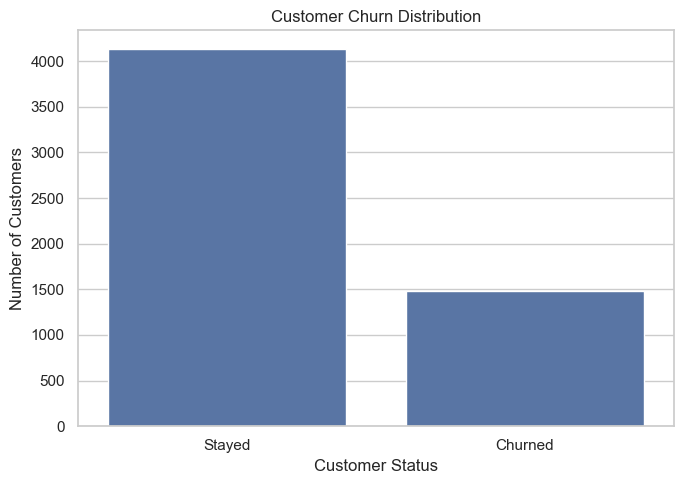

Chart saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\01_churn_distribution.png


In [37]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="ChurnLabel",
    order=["Stayed", "Churned"]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()

chart_path = FIGURES_DIR / "01_churn_distribution.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

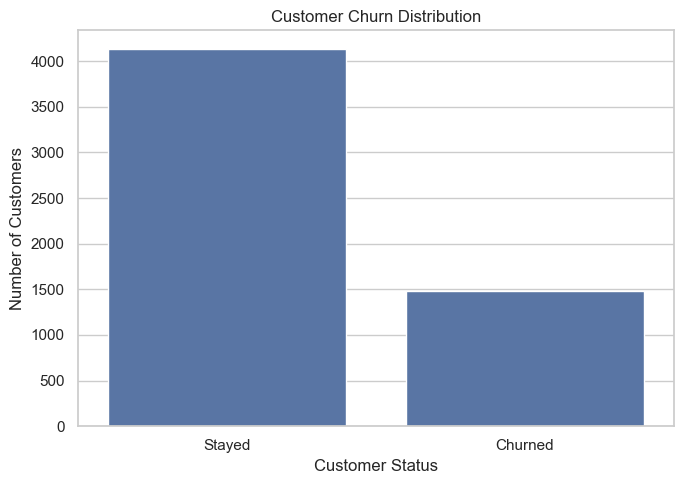

Chart saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\01_churn_distribution.png


In [38]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=eda_df,
    x="ChurnLabel",
    order=["Stayed", "Churned"]
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")
plt.tight_layout()

chart_path = FIGURES_DIR / "01_churn_distribution.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

In [39]:
contract_summary = (
    eda_df
    .groupby("Contract", observed=True)["Churn"]
    .agg(
        Customers="size",
        Churned="sum",
        Churn_Rate="mean"
    )
    .reset_index()
)

contract_summary["Churn_Rate_Percentage"] = (
    contract_summary["Churn_Rate"] * 100
).round(2)

contract_summary

,Contract,Customers,Churned,Churn_Rate,Churn_Rate_Percentage
0,Month-to-month,3078,1313,0.426576,42.66
1,One year,1182,132,0.111675,11.17
2,Two year,1356,40,0.029499,2.95


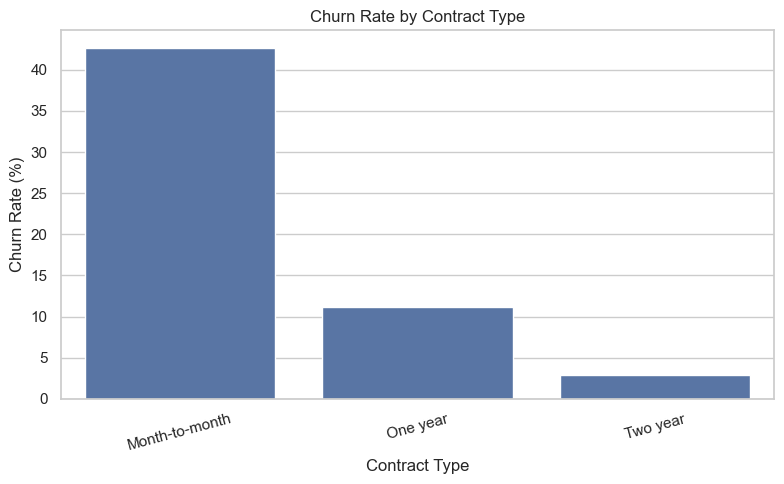

Chart saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\02_contract_churn_rate.png


In [40]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_summary,
    x="Contract",
    y="Churn_Rate_Percentage"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)

plt.tight_layout()

chart_path = FIGURES_DIR / "02_contract_churn_rate.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")

plt.show()

print("Chart saved to:", chart_path)

In [41]:
tenure_summary = (
    eda_df.groupby("ChurnLabel")["tenure"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

tenure_summary["mean"] = tenure_summary["mean"].round(2)
tenure_summary["median"] = tenure_summary["median"].round(2)

tenure_summary

,ChurnLabel,count,mean,median
0,Churned,1485,18.35,10.0
1,Stayed,4131,37.50,37.0


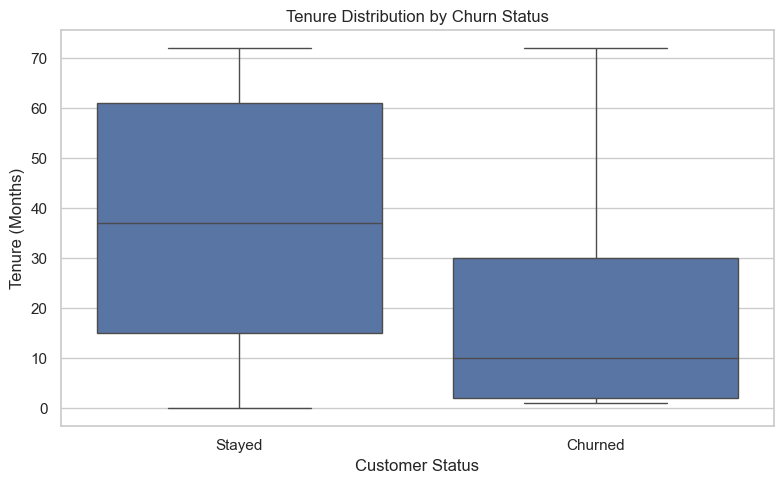

Chart saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\03_tenure_vs_churn.png


In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=eda_df,
    x="ChurnLabel",
    y="tenure",
    order=["Stayed", "Churned"]
)

plt.title("Tenure Distribution by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Tenure (Months)")
plt.tight_layout()

chart_path = FIGURES_DIR / "03_tenure_vs_churn.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

In [43]:
monthly_charges_summary = (
    eda_df.groupby("ChurnLabel")["MonthlyCharges"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

monthly_charges_summary["mean"] = (
    monthly_charges_summary["mean"].round(2)
)

monthly_charges_summary["median"] = (
    monthly_charges_summary["median"].round(2)
)

monthly_charges_summary

,ChurnLabel,count,mean,median
0,Churned,1485,75.13,79.9
1,Stayed,4131,61.22,64.5


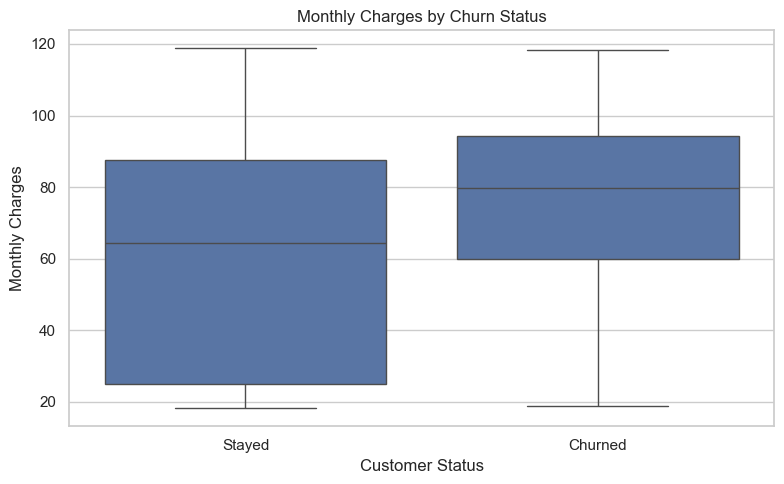

Chart saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\04_monthly_charges_vs_churn.png


In [44]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=eda_df,
    x="ChurnLabel",
    y="MonthlyCharges",
    order=["Stayed", "Churned"]
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Customer Status")
plt.ylabel("Monthly Charges")
plt.tight_layout()

chart_path = FIGURES_DIR / "04_monthly_charges_vs_churn.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

In [45]:
target_summary = (
    eda_df["ChurnLabel"]
    .value_counts()
    .rename_axis("Churn Status")
    .reset_index(name="Customers")
)

target_summary["Percentage (%)"] = (
    target_summary["Customers"] / len(eda_df) * 100
).round(2)

target_summary

,Churn Status,Customers,Percentage (%)
0,Stayed,4131,73.56
1,Churned,1485,26.44


In [46]:

# 1. Target summary
target_summary = (
    eda_df["ChurnLabel"]
    .value_counts()
    .rename_axis("Churn Status")
    .reset_index(name="Customers")
)

target_summary["Percentage (%)"] = (
    target_summary["Customers"] / len(eda_df) * 100
).round(2)


# 2. Contract summary
contract_summary = (
    eda_df.groupby("Contract")["Churn"]
    .agg(["count", "mean"])
    .reset_index()
)

contract_summary["Churn Rate (%)"] = (
    contract_summary["mean"] * 100
).round(2)

contract_summary = contract_summary.drop(columns="mean")


# 3. Tenure summary
tenure_summary = (
    eda_df.groupby("ChurnLabel")["tenure"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

tenure_summary["mean"] = tenure_summary["mean"].round(2)
tenure_summary["median"] = tenure_summary["median"].round(2)


# 4. Monthly charges summary
monthly_charges_summary = (
    eda_df.groupby("ChurnLabel")["MonthlyCharges"]
    .agg(["count", "mean", "median"])
    .reset_index()
)

monthly_charges_summary["mean"] = (
    monthly_charges_summary["mean"].round(2)
)

monthly_charges_summary["median"] = (
    monthly_charges_summary["median"].round(2)
)


# 5. Save summaries
target_summary.to_csv(
    REPORTS_DIR / "day4_target_summary.csv",
    index=False
)

contract_summary.to_csv(
    REPORTS_DIR / "day4_contract_summary.csv",
    index=False
)

tenure_summary.to_csv(
    REPORTS_DIR / "day4_tenure_summary.csv",
    index=False
)

monthly_charges_summary.to_csv(
    REPORTS_DIR / "day4_monthly_charges_summary.csv",
    index=False
)

split_comparison.to_csv(
    REPORTS_DIR / "day4_split_summary.csv",
    index=False
)

print("All Day 4 summary files saved successfully.")

All Day 4 summary files saved successfully.


In [47]:
print("TARGET SUMMARY")
display(target_summary)

print("\nCONTRACT SUMMARY")
display(contract_summary)

print("\nTENURE SUMMARY")
display(tenure_summary)

print("\nMONTHLY CHARGES SUMMARY")
display(monthly_charges_summary)

print("\nSPLIT SUMMARY")
display(split_comparison)

TARGET SUMMARY


,Churn Status,Customers,Percentage (%)
0,Stayed,4131,73.56
1,Churned,1485,26.44



CONTRACT SUMMARY


,Contract,count,Churn Rate (%)
0,Month-to-month,3078,42.66
1,One year,1182,11.17
2,Two year,1356,2.95



TENURE SUMMARY


,ChurnLabel,count,mean,median
0,Churned,1485,18.35,10.0
1,Stayed,4131,37.50,37.0



MONTHLY CHARGES SUMMARY


,ChurnLabel,count,mean,median
0,Churned,1485,75.13,79.9
1,Stayed,4131,61.22,64.5



SPLIT SUMMARY


,Dataset,Rows,Churn Rate (%)
0,Full,7021,26.45
1,Training,5616,26.44
2,Test,1405,26.48


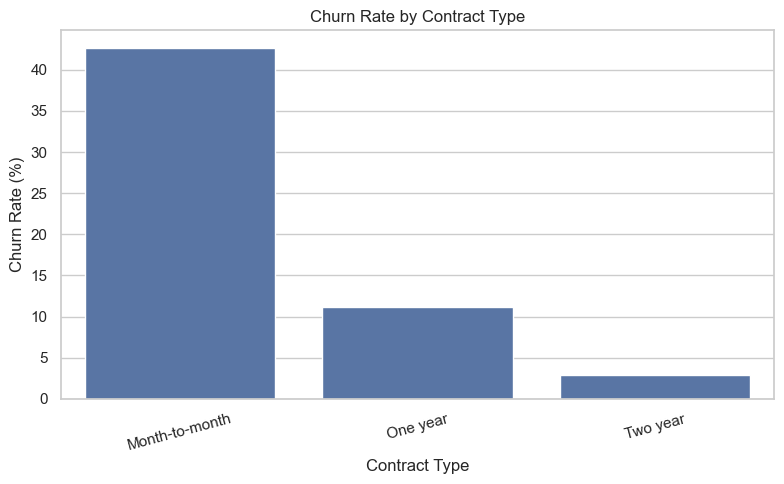

Chart saved to: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\02_contract_churn_rate.png


In [48]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=contract_summary,
    x="Contract",
    y="Churn Rate (%)"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=15)
plt.tight_layout()

chart_path = FIGURES_DIR / "02_contract_churn_rate.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print("Chart saved to:", chart_path)

In [49]:
# Verify all Day 4 charts
expected_charts = [
    "01_churn_distribution.png",
    "02_contract_churn_rate.png",
    "03_tenure_vs_churn.png",
    "04_monthly_charges_vs_churn.png"
]

print("DAY 4 CHART CHECK")
print("-" * 40)

for chart in expected_charts:
    path = FIGURES_DIR / chart
    print("✓" if path.exists() else "✗", chart)


# Verify summary files
expected_reports = [
    "day4_target_summary.csv",
    "day4_contract_summary.csv",
    "day4_tenure_summary.csv",
    "day4_monthly_charges_summary.csv",
    "day4_split_summary.csv"
]

print("\nDAY 4 SUMMARY FILE CHECK")
print("-" * 40)

for report in expected_reports:
    path = REPORTS_DIR / report
    print("✓" if path.exists() else "✗", report)

DAY 4 CHART CHECK
----------------------------------------
✓ 01_churn_distribution.png
✓ 02_contract_churn_rate.png
✓ 03_tenure_vs_churn.png
✓ 04_monthly_charges_vs_churn.png

DAY 4 SUMMARY FILE CHECK
----------------------------------------
✓ day4_target_summary.csv
✓ day4_contract_summary.csv
✓ day4_tenure_summary.csv
✓ day4_monthly_charges_summary.csv
✓ day4_split_summary.csv


In [50]:
train_df
eda_df
FIGURES_DIR
REPORTS_DIR
CHURN_COLORS


{'Stayed': '#4C78A8', 'Churned': '#E45756'}

---
# Day 5 — Service and Billing Feature Analysis

## Objectives

- Compare churn rates across payment method, internet service,
  tech support, online security, and paperless billing.
- Build a combined churn-rate comparison chart.
- Examine the interaction between contract type and internet service.
- Write final Week 1 business insights.
---

In [51]:
def churn_rate_by_feature(data, feature, order=None):
    """
    Calculate customer counts and churn rate for each category.
    Uses the supplied training dataframe.
    """
    summary = (
        data
        .groupby(feature, observed=True)["Churn"]
        .agg(
            Customers="size",
            Churned="sum",
            Churn_Rate="mean"
        )
        .reset_index()
    )

    summary["Churn_Rate_Percentage"] = (
        summary["Churn_Rate"] * 100
    ).round(2)

    if order is not None:
        summary = (
            summary
            .set_index(feature)
            .reindex(order)
            .reset_index()
        )

    return summary

In [52]:
def plot_churn_rate_bar(
    summary,
    feature,
    title,
    filename,
    figsize=(9, 5),
    rotate_labels=False
):
    """
    Plot churn rate by category and save the figure.
    """

    fig, ax = plt.subplots(figsize=figsize)

    bars = ax.bar(
        summary[feature].astype(str),
        summary["Churn_Rate_Percentage"],
        color="#E76F51",
        width=0.6
    )

    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_title(
        title,
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    ax.set_xlabel(feature)
    ax.set_ylabel("Churn Rate (%)")

    ax.set_ylim(
        0,
        summary["Churn_Rate_Percentage"].max() + 10
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if rotate_labels:
        plt.xticks(rotation=20, ha="right")

    plt.tight_layout()

    output_path = FIGURES_DIR / filename

    fig.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print("Saved:", output_path)

In [53]:
payment_summary = churn_rate_by_feature(
    eda_df,
    "PaymentMethod"
)

payment_summary = (
    payment_summary
    .sort_values(
        "Churn_Rate_Percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

payment_summary

,PaymentMethod,Customers,Churned,Churn_Rate,Churn_Rate_Percentage
0,Electronic check,1905,861,0.451969,45.20
1,Mailed check,1269,234,0.184397,18.44
2,Bank transfer (automatic),1229,206,0.167616,16.76
3,Credit card (automatic),1213,184,0.151690,15.17


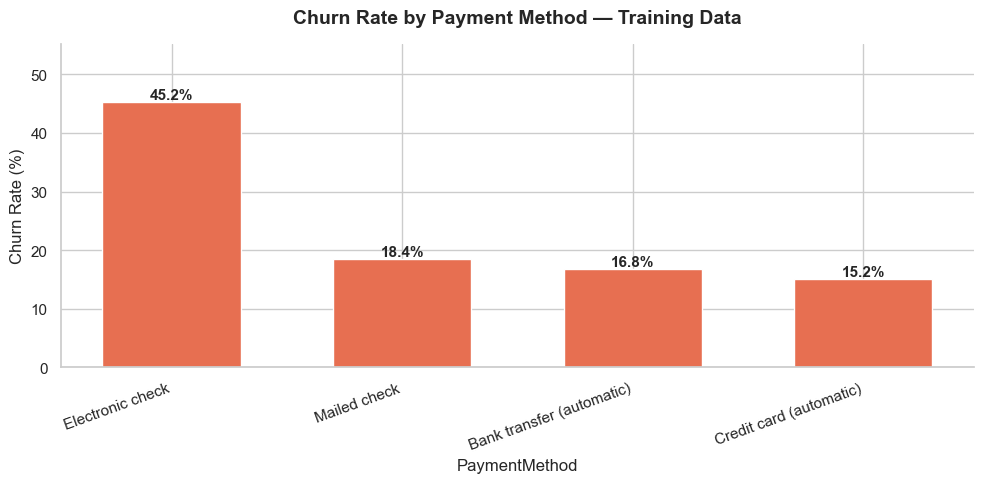

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\05_payment_method_churn_rate.png


In [54]:
plot_churn_rate_bar(
    payment_summary,
    feature="PaymentMethod",
    title="Churn Rate by Payment Method — Training Data",
    filename="05_payment_method_churn_rate.png",
    figsize=(10, 5),
    rotate_labels=True
)

In [55]:
internet_summary = churn_rate_by_feature(
    eda_df,
    "InternetService",
    order=["DSL", "Fiber optic", "No"]
)

internet_summary

,InternetService,Customers,Churned,Churn_Rate,Churn_Rate_Percentage
0,DSL,1933,358,0.185204,18.52
1,Fiber optic,2469,1045,0.423248,42.32
2,No,1214,82,0.067545,6.75


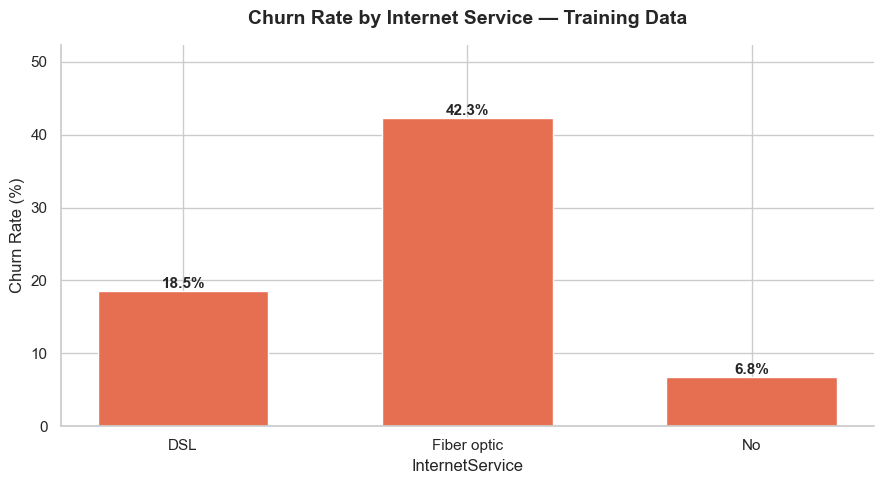

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\06_internet_service_churn_rate.png


In [56]:
plot_churn_rate_bar(
    internet_summary,
    feature="InternetService",
    title="Churn Rate by Internet Service — Training Data",
    filename="06_internet_service_churn_rate.png"
)

In [57]:
service_order = [
    "Yes",
    "No",
    "No internet service"
]

tech_support_summary = churn_rate_by_feature(
    eda_df,
    "TechSupport",
    order=service_order
)

online_security_summary = churn_rate_by_feature(
    eda_df,
    "OnlineSecurity",
    order=service_order
)

print("Tech Support:")
display(tech_support_summary)

print("\nOnline Security:")
display(online_security_summary)

Tech Support:


,TechSupport,Customers,Churned,Churn_Rate,Churn_Rate_Percentage
0,Yes,1622,250,0.154131,15.41
1,No,2780,1153,0.414748,41.47
2,No internet service,1214,82,0.067545,6.75



Online Security:


,OnlineSecurity,Customers,Churned,Churn_Rate,Churn_Rate_Percentage
0,Yes,1609,238,0.147918,14.79
1,No,2793,1165,0.417114,41.71
2,No internet service,1214,82,0.067545,6.75


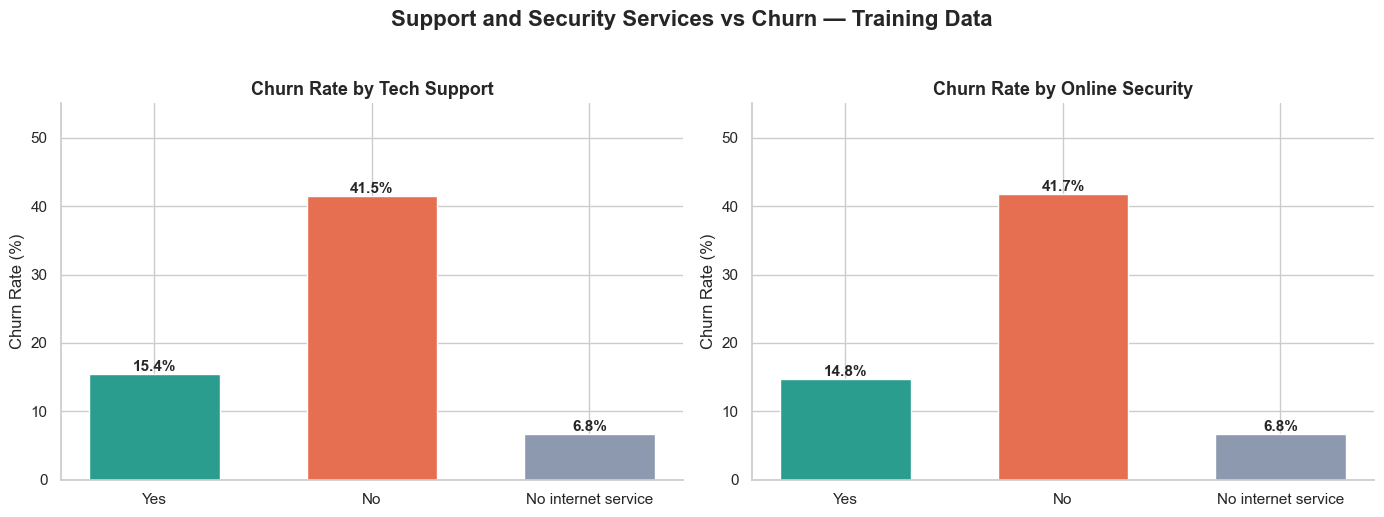

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\07_support_security_churn_rate.png


In [58]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

for ax, summary, name in [
    (
        axes[0],
        tech_support_summary,
        "Tech Support"
    ),
    (
        axes[1],
        online_security_summary,
        "Online Security"
    ),
]:

    bars = ax.bar(
        summary.iloc[:, 0].astype(str),
        summary["Churn_Rate_Percentage"],
        color=["#2A9D8F", "#E76F51", "#8D99AE"],
        width=0.6
    )

    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    ax.set_title(
        f"Churn Rate by {name}",
        fontsize=13,
        fontweight="bold"
    )

    ax.set_ylabel("Churn Rate (%)")
    ax.set_ylim(0, 55)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Support and Security Services vs Churn — Training Data",
    fontsize=16,
    fontweight="bold",
    y=1.03
)

plt.tight_layout()

output_path = (
    FIGURES_DIR /
    "07_support_security_churn_rate.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", output_path)

In [59]:
paperless_summary = churn_rate_by_feature(
    eda_df,
    "PaperlessBilling",
    order=["Yes", "No"]
)

paperless_summary

,PaperlessBilling,Customers,Churned,Churn_Rate,Churn_Rate_Percentage
0,Yes,3365,1125,0.334324,33.43
1,No,2251,360,0.159929,15.99


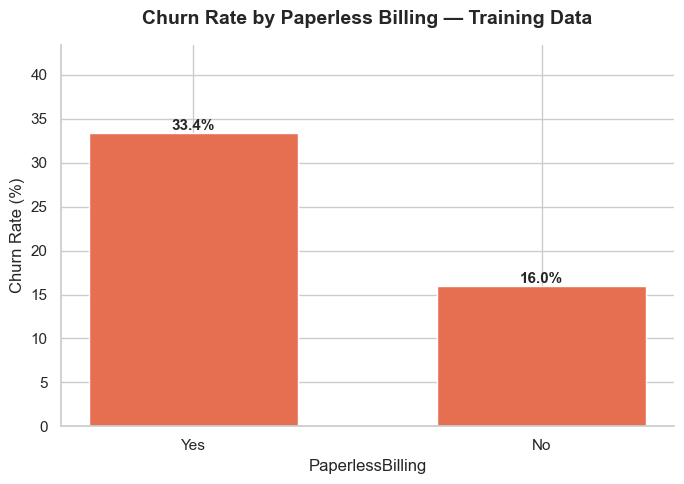

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\08_paperless_billing_churn_rate.png


In [60]:
plot_churn_rate_bar(
    paperless_summary,
    feature="PaperlessBilling",
    title="Churn Rate by Paperless Billing — Training Data",
    filename="08_paperless_billing_churn_rate.png",
    figsize=(7, 5)
)

In [61]:
payment_summary
internet_summary
tech_support_summary
online_security_summary
paperless_summary

,PaperlessBilling,Customers,Churned,Churn_Rate,Churn_Rate_Percentage
0,Yes,3365,1125,0.334324,33.43
1,No,2251,360,0.159929,15.99


## Day 5 — Combined High-Risk Segment Analysis

In [62]:
# Define key high-risk customer segments
risk_segments = {
    "Month-to-month contract": eda_df["Contract"].eq("Month-to-month"),
    "Electronic check": eda_df["PaymentMethod"].eq("Electronic check"),
    "Fiber optic": eda_df["InternetService"].eq("Fiber optic"),
    "No online security": eda_df["OnlineSecurity"].eq("No"),
    "No tech support": eda_df["TechSupport"].eq("No"),
    "Paperless billing": eda_df["PaperlessBilling"].eq("Yes")
}

risk_rows = []

for segment, condition in risk_segments.items():
    segment_data = eda_df.loc[condition, "Churn"]

    risk_rows.append({
        "Risk_Segment": segment,
        "Customers": len(segment_data),
        "Churned": segment_data.sum(),
        "Churn_Rate_Percentage": round(segment_data.mean() * 100, 2)
    })

risk_segment_summary = (
    pd.DataFrame(risk_rows)
    .sort_values("Churn_Rate_Percentage", ascending=True)
    .reset_index(drop=True)
)

risk_segment_summary

,Risk_Segment,Customers,Churned,Churn_Rate_Percentage
0,Paperless billing,3365,1125,33.43
1,No tech support,2780,1153,41.47
2,No online security,2793,1165,41.71
3,Fiber optic,2469,1045,42.32
4,Month-to-month contract,3078,1313,42.66
5,Electronic check,1905,861,45.20


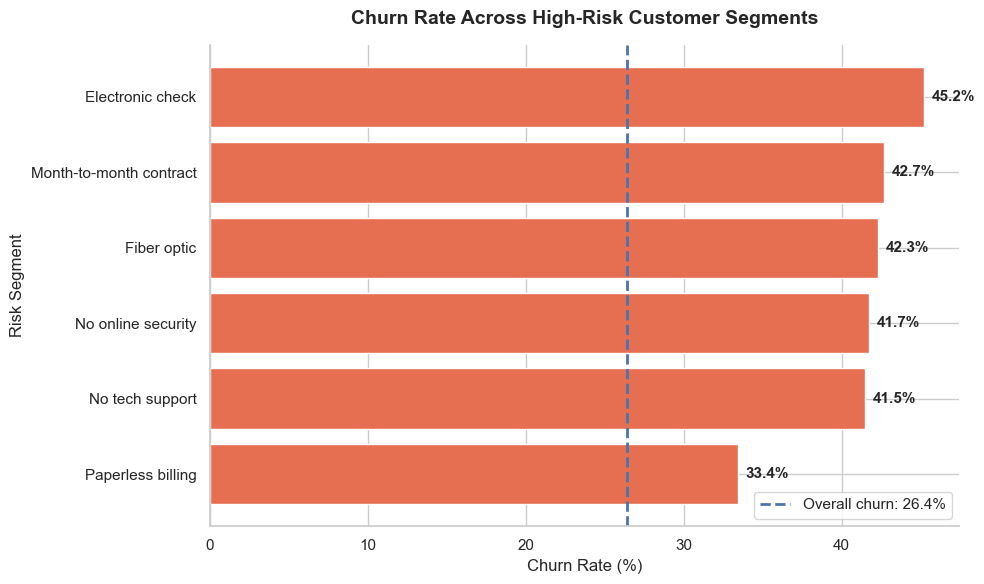

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\09_risk_segment_comparison.png


In [63]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    risk_segment_summary["Risk_Segment"],
    risk_segment_summary["Churn_Rate_Percentage"],
    color="#E76F51"
)

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

overall_churn = eda_df["Churn"].mean() * 100

ax.axvline(
    overall_churn,
    linestyle="--",
    linewidth=2,
    label=f"Overall churn: {overall_churn:.1f}%"
)

ax.set_title(
    "Churn Rate Across High-Risk Customer Segments",
    fontsize=14,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Churn Rate (%)")
ax.set_ylabel("Risk Segment")
ax.legend()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

output_path = FIGURES_DIR / "09_risk_segment_comparison.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()
print("Saved:", output_path)

In [64]:
risk_segment_summary.to_csv(
    REPORTS_DIR / "day5_risk_segment_comparison.csv",
    index=False
)

print("Saved:", REPORTS_DIR / "day5_risk_segment_comparison.csv")

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\day5_risk_segment_comparison.csv


### Contract × Internet Service Interaction

In [65]:
interaction_table = (
    eda_df
    .pivot_table(
        index="Contract",
        columns="InternetService",
        values="Churn",
        aggfunc="mean",
        observed=True
    ) * 100
).round(1)

interaction_table = interaction_table.reindex(
    ["Month-to-month", "One year", "Two year"]
)

interaction_table

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.0,54.7,17.5
One year,8.8,19.9,2.3
Two year,1.6,8.3,0.8


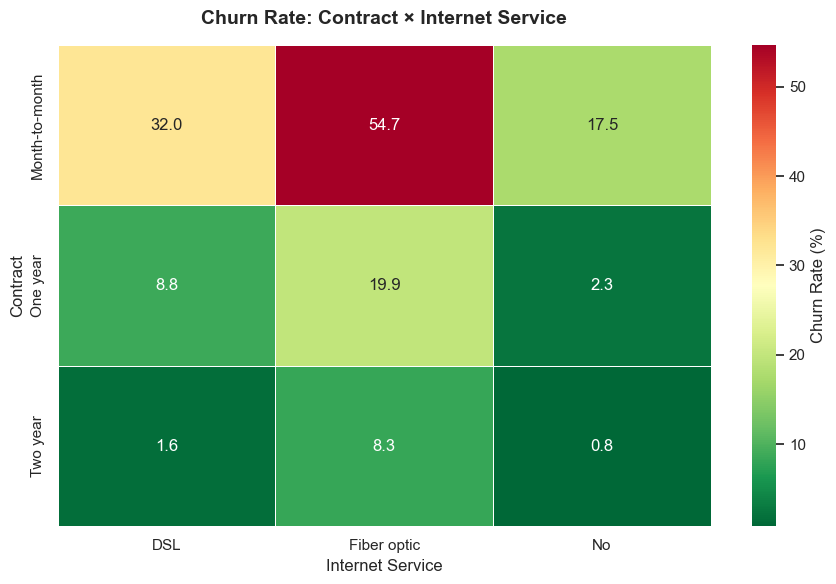

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\figures\10_contract_internet_heatmap.png


In [66]:
fig, ax = plt.subplots(figsize=(9, 6))

sns.heatmap(
    interaction_table,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar_kws={"label": "Churn Rate (%)"},
    ax=ax
)

ax.set_title(
    "Churn Rate: Contract × Internet Service",
    fontsize=14,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Internet Service")
ax.set_ylabel("Contract")

plt.tight_layout()

output_path = FIGURES_DIR / "10_contract_internet_heatmap.png"
fig.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()
print("Saved:", output_path)

In [67]:
interaction_table.to_csv(
    REPORTS_DIR / "day5_contract_internet_interaction.csv"
)

print(
    "Saved:",
    REPORTS_DIR / "day5_contract_internet_interaction.csv"
)

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\day5_contract_internet_interaction.csv


In [68]:
summary_files = {
    "day5_payment_summary.csv": payment_summary,
    "day5_internet_summary.csv": internet_summary,
    "day5_tech_support_summary.csv": tech_support_summary,
    "day5_online_security_summary.csv": online_security_summary,
    "day5_paperless_summary.csv": paperless_summary,
    "day5_risk_segment_comparison.csv": risk_segment_summary,
    "day5_contract_internet_interaction.csv": interaction_table
}

for filename, dataframe in summary_files.items():
    output_path = REPORTS_DIR / filename
    dataframe.to_csv(output_path)
    print("Saved:", output_path)

Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\day5_payment_summary.csv
Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\day5_internet_summary.csv
Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\day5_tech_support_summary.csv
Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\day5_online_security_summary.csv
Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\day5_paperless_summary.csv
Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\day5_risk_segment_comparison.csv
Saved: c:\Users\gurmeet singh\Projects\customer-churn-retention-engine\reports\day5_contract_internet_interaction.csv


In [69]:
risk_segment_summary

,Risk_Segment,Customers,Churned,Churn_Rate_Percentage
0,Paperless billing,3365,1125,33.43
1,No tech support,2780,1153,41.47
2,No online security,2793,1165,41.71
3,Fiber optic,2469,1045,42.32
4,Month-to-month contract,3078,1313,42.66
5,Electronic check,1905,861,45.20


In [70]:
interaction_table

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.0,54.7,17.5
One year,8.8,19.9,2.3
Two year,1.6,8.3,0.8
